DUVIDAS \
1.no kaggle diz que a key é o unique identifyer mas entao o que é a primeira coluna e podemos apagar a key pq é igual á outra \
2.lidar com os null fare values
3. apagamos os negative fare amounts?

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">

<h1 style="margin-bottom:0;"><b> Machine Learning II - Project 1</b></h1>
<br>

<h1 style="margin-top:5px; color:#0047AB;"><b>"Uber Fares" </b></h1>

<h2 style="color:#0047AB; margin-top:-5px;"><b>Data Preprocessing & Exploratory Analysis</b></h2>


<h3><b> Group _o melhor muahahahha (malefico) </b></h3>
    
<b>Carlota Marto</b> — 20241729</li>\
<b>Francisca Teixeira</b> — 20241702</li>
</ul>
<h4>LCD  —  Teachers: Ivo Bernardo  — 2025/26 </h4>

</div>


<div style="background-color:#EFF5FF; padding:15px; border-radius:10px;">

**Table of Contents**

**1.Introduction**

1.1. Project Context and Goal

**Part A – Data Understanding & Cleaning**

2.1. Imports\
2.2. Preprocessing Data
<ul style="margin-top:-10px;">
    
  2.2.1. Duplicate Records \
  2.2.2  Handling Inconsistencies \
  2.2.3. Missing Values - Categorical(3) / Numerical (3)\
  2.2.4. Outliers  \
  2.2.5. Adjusting Data Types 
</ul>

**Part B – Feature Engineering & ABT Construction**



<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>1. Introduction </b></h3>


 <div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b> 1.1. Project Context and Goal

Introduction to Uber's Challenge: Explore how Uber's massive daily operations necessitate accurate fare prediction for optimal business strategies.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part A – Data Understanding & Cleaning </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.1 Imports

Import of Necessary Libraries:

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from matplotlib.colors import LinearSegmentedColormap

# Suppress warnings only after confirming they're not critical
warnings.filterwarnings('ignore')

# Configure blue color palette for all visualizations
BLUE_MAIN = '#1f77b4'      # Main blue
BLUE_LIGHT = '#6baed6'     # Light blue
BLUE_DARK = '#0d47a1'      # Dark blue
BLUE_PALE = '#e3f2fd'      # Pale blue for backgrounds
BLUE_MEDIUM = '#4292c6'    # Medium blue

# Create custom blue colormap for heatmaps
blue_cmap = LinearSegmentedColormap.from_list(
    "blue_custom",
    [BLUE_PALE, BLUE_LIGHT, BLUE_MAIN, BLUE_DARK]
)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette([BLUE_MAIN, BLUE_LIGHT, BLUE_MEDIUM, BLUE_DARK])

# Configuration
CONFIG = {
    'data_path': 'uber.csv',
    'random_state': 42,
    'figsize_large': (18, 10),
    'figsize_medium': (14, 8),
    'figsize_small': (10, 8),
    'dpi': 100
}

print("Libraries imported successfully")
print(f"   Blue color scheme: {BLUE_MAIN}, {BLUE_LIGHT}, {BLUE_DARK}")

Libraries imported successfully
   Blue color scheme: #1f77b4, #6baed6, #0d47a1


Import of the given Dataset:

In [55]:
df = pd.read_csv('uber.csv', index_col = 0)
print("The dataset has {} rows and {} columns".format(df.shape[0], df.shape[1]))
print("\nFirst 5 rows of the dataset:")
display(df.head())

# Display column names
print("\nColumn names:")
print(list(df.columns))

The dataset has 200000 rows and 8 columns

First 5 rows of the dataset:


,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5



Column names:
['key', 'fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


**Atributes description:** \
**key:** Unique trip identifier.\
**fare_amount:** Cost of trip (in USD).\
**pickup_datetime:** Timestamp of trip start.\
**passenger_count:** Number of passengers.\
**pickup_longitude & pickup_latitude:** Initial pickup coordinates.\
**dropoff_longitude & dropoff_latitude:** Drop-off coordinates.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2. Preprocessing Data
   

In [57]:
def display_data_overview(df):
    """Display comprehensive dataset information."""
    
    print("\nBASIC INFORMATION:")
    print(f"Total records: {len(df):,}")
    print(f"Total features: {len(df.columns)}")
    
    print("\nCOLUMN DESCRIPTIONS:")
    descriptions = {
        'key': 'Unique trip identifier',
        'fare_amount': 'Cost of trip (USD)',
        'pickup_datetime': 'Timestamp of trip start',
        'passenger_count': 'Number of passengers',
        'pickup_longitude': 'Initial pickup longitude',
        'pickup_latitude': 'Initial pickup latitude',
        'dropoff_longitude': 'Drop-off longitude',
        'dropoff_latitude': 'Drop-off latitude'
    }
    
    for col in df.columns:
        desc = descriptions.get(col, 'No description available')
        dtype = df[col].dtype
        nulls = df[col].isna().sum()
        null_pct = (nulls / len(df)) * 100
        print(f"  • {col}: {desc}")
        print(f"    - Type: {dtype}, Nulls: {nulls} ({null_pct:.1f}%)")
    
    print("\nBASIC STATISTICS:")
    display(df.describe())
    
    print("\nDATA TYPES SUMMARY:")
    dtype_counts = df.dtypes.value_counts()
    for dtype, count in dtype_counts.items():
        print(f"  • {dtype}: {count} columns")

display_data_overview(df)

# Check for missing values
print("MISSING VALUES SUMMARY")
missing_values = df.isnull().sum()
missing_pct = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Percentage': missing_pct
})
display(missing_df[missing_df['Missing Count'] > 0])


BASIC INFORMATION:
Total records: 200,000
Total features: 8

COLUMN DESCRIPTIONS:
  • key: Unique trip identifier
    - Type: object, Nulls: 0 (0.0%)
  • fare_amount: Cost of trip (USD)
    - Type: float64, Nulls: 0 (0.0%)
  • pickup_datetime: Timestamp of trip start
    - Type: object, Nulls: 0 (0.0%)
  • pickup_longitude: Initial pickup longitude
    - Type: float64, Nulls: 0 (0.0%)
  • pickup_latitude: Initial pickup latitude
    - Type: float64, Nulls: 0 (0.0%)
  • dropoff_longitude: Drop-off longitude
    - Type: float64, Nulls: 1 (0.0%)
  • dropoff_latitude: Drop-off latitude
    - Type: float64, Nulls: 1 (0.0%)
  • passenger_count: Number of passengers
    - Type: int64, Nulls: 0 (0.0%)

BASIC STATISTICS:


,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000



DATA TYPES SUMMARY:
  • float64: 5 columns
  • object: 2 columns
  • int64: 1 columns
MISSING VALUES SUMMARY


,Missing Count,Percentage
dropoff_longitude,1,0.0005
dropoff_latitude,1,0.0005


In [86]:
print("DATA TYPE CORRECTIONS")

# Display current data types before conversion
print("\nCURRENT DATA TYPES (BEFORE):")
print(df.dtypes)

print("\n1. CONVERTING 'pickup_datetime' TO DATETIME")
print("-"*40)

if 'pickup_datetime' in df.columns:
    # Display sample before conversion
    print(f"   Sample before: {df['pickup_datetime'].iloc[0]}")
    print(f"   Current type: {df['pickup_datetime'].dtype}")
    
    # Count records with invalid datetime format
    invalid_dates = 0
    try:
        # Attempt conversion with UTC handling
        df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True)
        print(f"   Conversion successful!")
        print(f"   Sample after: {df['pickup_datetime'].iloc[0]}")
        print(f"   New type: {df['pickup_datetime'].dtype}")
        
        # Check date range
        min_date = df['pickup_datetime'].min()
        max_date = df['pickup_datetime'].max()
        print(f"   Date range: {min_date} to {max_date}")
        
    except Exception as e:
        print(f"   Conversion error: {e}")
        print(f"   Attempting with error handling...")
        df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'], utc=True, errors='coerce')
        
        # Check for failed conversions
        failed_conversions = df['pickup_datetime'].isna().sum()
        if failed_conversions > 0:
            print(f"   {failed_conversions} records failed to convert (set to NaT)")
        else:
            print(f"   All records converted successfully!")

DATA TYPE CORRECTIONS

CURRENT DATA TYPES (BEFORE):
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
distance_km                      float64
dtype: object

1. CONVERTING 'pickup_datetime' TO DATETIME
----------------------------------------
   Sample before: 2015-05-07 19:52:06+00:00
   Current type: datetime64[ns, UTC]
   Conversion successful!
   Sample after: 2015-05-07 19:52:06+00:00
   New type: datetime64[ns, UTC]
   Date range: 2009-01-01 01:15:22+00:00 to 2015-06-30 23:40:39+00:00


In [87]:

print("\n2. CONVERTING 'passenger_count' TO INTEGER")
print("-"*40)

if 'passenger_count' in df.columns:
    print(f"   Current type: {df['passenger_count'].dtype}")
    print(f"   Sample before: {df['passenger_count'].iloc[:5].tolist()}")
    
    # Check for non-integer values
    non_integer_mask = df['passenger_count'] % 1 != 0
    non_integer_count = non_integer_mask.sum()
    
    if non_integer_count > 0:
        print(f"   Found {non_integer_count} non-integer values:")
        print(f"      Examples: {df[non_integer_mask]['passenger_count'].iloc[:3].tolist()}")
        print(f"   Converting to integer (rounding down)...")
        df['passenger_count'] = df['passenger_count'].astype(int)
    else:
        print(f"   All values are integers")
        df['passenger_count'] = df['passenger_count'].astype(int)
    
    print(f"   New type: {df['passenger_count'].dtype}")
    print(f"   Unique values: {sorted(df['passenger_count'].unique())}")


2. CONVERTING 'passenger_count' TO INTEGER
----------------------------------------
   Current type: int64
   Sample before: [1, 1, 1, 3, 5]
   All values are integers
   New type: int64
   Unique values: [0, 1, 2, 3, 4, 5, 6, 208]


In [89]:
print("\n3. VERIFYING 'fare_amount' TYPE")
print("-"*40)

if 'fare_amount' in df.columns:
    print(f"   Current type: {df['fare_amount'].dtype}")
    
    # Convert if needed
    if df['fare_amount'].dtype != 'float64':
        print(f"   Converting to float64...")
        df['fare_amount'] = df['fare_amount'].astype(float)
        print(f"   Converted to float64")
    else:
        print(f"   Already correct type (float64)")
    
    print(f"   Value range: ${df['fare_amount'].min():.2f} to ${df['fare_amount'].max():.2f}")


3. VERIFYING 'fare_amount' TYPE
----------------------------------------
   Current type: float64
   Already correct type (float64)
   Value range: $-52.00 to $499.00


In [90]:
print("\n4. VALIDATING COORDINATE COLUMNS")
print("-"*40)

coordinate_cols = ['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']

for col in coordinate_cols:
    if col in df.columns:
        # Ensure float type
        if df[col].dtype != 'float64':
            print(f"   Converting {col} to float64...")
            df[col] = df[col].astype(float)
        
        # Check range
        min_val = df[col].min()
        max_val = df[col].max()
        
        if 'longitude' in col:
            expected_range = (-180, 180)
        else:  # latitude
            expected_range = (-90, 90)
        
        print(f"   • {col}:")
        print(f"     - Range: [{min_val:.2f}, {max_val:.2f}]")
        
        # Check for out-of-range values
        out_of_range = (df[col] < expected_range[0]) | (df[col] > expected_range[1])
        out_of_range_count = out_of_range.sum()
        
        if out_of_range_count > 0:
            print(f"     - {out_of_range_count} values outside expected range {expected_range}")
        else:
            print(f"     - All values within expected range")


4. VALIDATING COORDINATE COLUMNS
----------------------------------------
   • pickup_longitude:
     - Range: [-1340.65, 57.42]
     - 7 values outside expected range (-180, 180)
   • pickup_latitude:
     - Range: [-74.02, 1644.42]
     - 4 values outside expected range (-90, 90)
   • dropoff_longitude:
     - Range: [-3356.67, 1153.57]
     - 3 values outside expected range (-180, 180)
   • dropoff_latitude:
     - Range: [-881.99, 872.70]
     - 3 values outside expected range (-90, 90)


In [92]:

print("DATA TYPE CORRECTIONS - SUMMARY")

print("\nUPDATED DATA TYPES (AFTER):")
print("-"*40)
print(df.dtypes)

print("\nMEMORY USAGE COMPARISON:")
print("-"*40)
print(f"   • Memory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")
print(f"   • Columns optimized: {len(df.columns)}")

# Verify critical conversions
print("\nCRITICAL CONVERSIONS VERIFIED:")
print("-"*40)
if 'pickup_datetime' in df.columns:
    print(f"   ✓ pickup_datetime: {df['pickup_datetime'].dtype} (datetime)")
if 'passenger_count' in df.columns:
    print(f"   ✓ passenger_count: {df['passenger_count'].dtype} (integer)")
if 'fare_amount' in df.columns:
    print(f"   ✓ fare_amount: {df['fare_amount'].dtype} (float)")
for col in coordinate_cols:
    if col in df.columns:
        print(f"   ✓ {col}: {df[col].dtype} (float)")


DATA TYPE CORRECTIONS - SUMMARY

UPDATED DATA TYPES (AFTER):
----------------------------------------
fare_amount                      float64
pickup_datetime      datetime64[ns, UTC]
pickup_longitude                 float64
pickup_latitude                  float64
dropoff_longitude                float64
dropoff_latitude                 float64
passenger_count                    int64
distance_km                      float64
dtype: object

MEMORY USAGE COMPARISON:
----------------------------------------
   • Memory usage: 17.76 MB
   • Columns optimized: 8

CRITICAL CONVERSIONS VERIFIED:
----------------------------------------
   ✓ pickup_datetime: datetime64[ns, UTC] (datetime)
   ✓ passenger_count: int64 (integer)
   ✓ fare_amount: float64 (float)
   ✓ pickup_longitude: float64 (float)
   ✓ pickup_latitude: float64 (float)
   ✓ dropoff_longitude: float64 (float)
   ✓ dropoff_latitude: float64 (float)


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.1. How to Handle Duplicate Records

We chose to handle the **duplicate records firstly** so that those records do not interfere with the imputation of the missing values.

In [60]:
# ============================================================================
# 2.3 Duplicate Records Handling
# ============================================================================

def check_duplicates(df):
    """
    Check and handle duplicate records.
    
    Returns:
    --------
    pd.DataFrame
        DataFrame with duplicates removed (if any)
    """
    print("DUPLICATE RECORDS CHECK")

    duplicate_count = df.duplicated().sum()
    duplicate_percentage = (duplicate_count / len(df)) * 100
    
    if duplicate_count > 0:
        print(f"Found {duplicate_count:,} duplicate records ({duplicate_percentage:.2f}%)")
        
        # Show first few duplicates for inspection
        duplicates = df[df.duplicated(keep=False)]
        print(f"\n   First 5 duplicate records:")
        display(duplicates.head())
        
        print("\n   Removing duplicates...")
        df_clean = df.drop_duplicates()
        print(f"Removed {duplicate_count:,} duplicates")
        print(f"   New shape: {df_clean.shape}")
    else:
        print("There aren´t duplicate records.")
        df_clean = df.copy()
    
    return df_clean

df = check_duplicates(df)

# Verify no duplicates remain
print("\nVERIFICATION:")
remaining_duplicates = df.duplicated().sum()
print(f"Duplicate records after cleaning: {remaining_duplicates}")

DUPLICATE RECORDS CHECK
There aren´t duplicate records.

VERIFICATION:
Duplicate records after cleaning: 0


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
<b>2.2.2. Handling Inconsistent Records

Datasets frequently contain logical inconsistencies (for instance, negative money). These records are technically present in the dataset but do not make any sense in a real-world context. This step is dedicated to identifying and correcting these errors, which are different from missing data.

We chose to handle these inconsistencies before the imputation of the missing values as we often use conditional imputation and, if they are left uncorrected, it distorts the groups statistics, such as the median, mean or mode. So in this way we ensure that the statistical basis is clean, stable and accurate.

In [62]:
def manage_columns(df):
    """
    Remove unnecessary columns (e.g., 'key' which duplicates info).
    """
    print("COLUMN MANAGEMENT")
    
    columns_to_drop = []
    
    # Check if 'key' column exists and is redundant
    if 'key' in df.columns:
        print("   'key' column detected - contains same timestamp info as pickup_datetime")
        print("   Sample comparison:")
        print(f"   - key sample: {df['key'].iloc[0]}")
        print(f"   - pickup_datetime sample: {df['pickup_datetime'].iloc[0]}")
        columns_to_drop.append('key')
    
    if columns_to_drop:
        df = df.drop(columns=columns_to_drop)
        print(f"\nRemoved columns: {columns_to_drop}")
        print(f"   New columns: {list(df.columns)}")
    else:
        print("No redundant columns found")
    
    return df

df = manage_columns(df)

print(f"\nDataset shape after column management: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

COLUMN MANAGEMENT
No redundant columns found

Dataset shape after column management: (200000, 7)
Remaining columns: ['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count']


In [63]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


The column 'key' doesn´t add info necessary (is the same time as pickup_datetime with millisecond).

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- First Rule: Negative Values - Every variable that corresponds to a price, time or number of passagers cannot be negative.

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Price** - fare_amount

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Null Values: 

In [70]:
print("ANALYZING ZERO FARE AMOUNTS")

# Identify zero fare records
null_fares = df[df['fare_amount'] == 0]
print(f"\nRecords with fare_amount = 0: {len(null_fares)}")

# Display the zero fare records
print("\nZero fare records:")
display(null_fares)

# Analyze patterns in zero fare records
print("\nANALYSIS OF ZERO FARE PATTERNS:")

# Case 1: Same pickup and dropoff coordinates (cancelled trips)
same_coords = null_fares[
    (null_fares['pickup_latitude'] == null_fares['dropoff_latitude']) &
    (null_fares['pickup_longitude'] == null_fares['dropoff_longitude'])
]
print(f"   • Cancelled trips (same coordinates): {len(same_coords)}")
if len(same_coords) > 0:
    print(f"     Example indices: {same_coords.index[:3].tolist()}")

# Case 2: Zero coordinates (data errors)
zero_coords_dropoff = null_fares[
    (null_fares['dropoff_longitude'] == 0) | 
    (null_fares['dropoff_latitude'] == 0)
]
print(f"   • Data errors (dropoff coordinates = 0): {len(zero_coords_dropoff)}")

zero_coords_pickup = null_fares[
    (null_fares['pickup_longitude'] == 0) | 
    (null_fares['pickup_latitude'] == 0)
]
print(f"   • Data errors (pickup coordinates = 0): {len(zero_coords_pickup)}")

# Case 3: Unusual coordinates
unusual_coords = null_fares[
    (null_fares['pickup_longitude'] > -70) |  # NYC area is around -74
    (null_fares['pickup_longitude'] < -80)
]
print(f"   • Unusual coordinate patterns: {len(unusual_coords)}")

ANALYZING ZERO FARE AMOUNTS

Records with fare_amount = 0: 5

Zero fare records:


,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
25344154,0.0,2015-04-22 23:25:07 UTC,-73.658897,40.805199,-73.658897,40.805199,1
22994576,0.0,2010-03-20 02:59:51 UTC,-73.994366,40.755395,-73.998718,40.854853,2
10649069,0.0,2015-01-04 03:51:13 UTC,-73.969475,40.807503,0.000000,0.000000,2
36776406,0.0,2015-02-17 08:48:08 UTC,-73.937714,40.758541,-73.937721,40.758541,1
44172118,0.0,2015-02-13 07:35:32 UTC,0.000000,0.000000,0.000000,0.000000,5



ANALYSIS OF ZERO FARE PATTERNS:
   • Cancelled trips (same coordinates): 2
     Example indices: [25344154, 44172118]
   • Data errors (dropoff coordinates = 0): 2
   • Data errors (pickup coordinates = 0): 1
   • Unusual coordinate patterns: 1


In [74]:
# Display specific cases mentioned in original analysis
print("\nSPECIFIC CASES FROM ANALYSIS:")
# Index 25344154 - same coordinates
if 25344154 in null_fares.index:
    print(f"   • Index 25344154: Same pickup and dropoff coordinates -> Canceled trip")
    
# Index 22994576 - travel occurred, needs fare estimation
if 22994576 in null_fares.index:
    print(f"   • Index 22994576: Travel occurred with zero fare -> Needs fare estimation")
    
# Index 10649069 - zero coordinates error
if 10649069 in null_fares.index:
    print(f"   • Index 10649069: Zero coordinates error -> Will be removed")
    
# Index 36776406 - almost same coordinates
if 36776406 in null_fares.index:
    print(f"   • Index 36776406: Almost same coordinates -> Canceled trip")
    
# Index 44172118 - zero coordinates error
if 44172118 in null_fares.index:
    print(f"   • Index 44172118: Zero coordinates error -> Will be removed")


SPECIFIC CASES FROM ANALYSIS:
   • Index 25344154: Same pickup and dropoff coordinates -> Canceled trip
   • Index 22994576: Travel occurred with zero fare -> Needs fare estimation
   • Index 10649069: Zero coordinates error -> Will be removed
   • Index 36776406: Almost same coordinates -> Canceled trip
   • Index 44172118: Zero coordinates error -> Will be removed


- **25344154** - pickup and dropoff travel coordinates are the same so we consider it was a **canceled uber**. It is not an error it is just a travel that didn´t occur. 
- **22994576** - travel occur - **error**. We can estimate the fare amount.
- **10649069** - dropoff_longitude and dropoff_latitude are both 0.0. We consider an **error** because all of the other observations are in the same zone and not travel half world. We cannot estimate the fare amount.
- **36776406** - pickup_latitude and dropoff_latitude	are the same and pickup_longitude and dropoff_longitude have a 0.000007 difference so we consider that was a **canceled travel.**
- **44172118** - the other values are all in the same zone (near -73 longitude, 40 latitude), so we consider the 0.0 a **error** and not a canceled travel with coordinates 0.0. We cannot estimate the fare amount.

Droping errors and mantaining canceled travels:

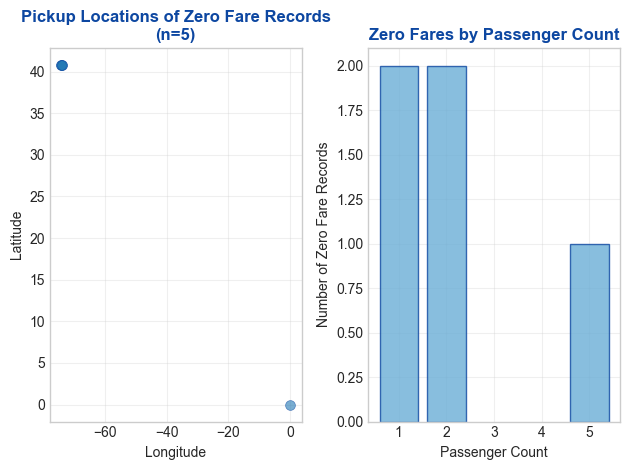

In [75]:
# Plot 1: Location of zero fare records
plt.subplot(1, 2, 1)
plt.scatter(null_fares['pickup_longitude'], null_fares['pickup_latitude'], 
            alpha=0.6, s=50, c=BLUE_MAIN, edgecolors=BLUE_DARK, linewidth=0.5)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Pickup Locations of Zero Fare Records\n(n={len(null_fares)})', 
          fontsize=12, fontweight='bold', color=BLUE_DARK)
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of zero fare records by passenger count
plt.subplot(1, 2, 2)
passenger_counts = null_fares['passenger_count'].value_counts().sort_index()
plt.bar(passenger_counts.index, passenger_counts.values, 
        color=BLUE_LIGHT, edgecolor=BLUE_DARK, alpha=0.8)
plt.xlabel('Passenger Count')
plt.ylabel('Number of Zero Fare Records')
plt.title('Zero Fares by Passenger Count', 
          fontsize=12, fontweight='bold', color=BLUE_DARK)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
print("REMOVING DATA ERRORS")

# Remove error rows with zero coordinates
rows_to_remove = []

# Check if error indices exist and add to removal list
error_indices = [10649069, 44172118]
for idx in error_indices:
    if idx in df.index:
        rows_to_remove.append(idx)
        print(f"   • Marking index {idx} for removal (zero coordinate error)")

# Remove the error rows
if rows_to_remove:
    df = df.drop(rows_to_remove, axis=0)
    print(f"\nRemoved {len(rows_to_remove)} error rows")
    print(f"   Removed indices: {rows_to_remove}")

print(f"\nDataset shape after removing errors: {df.shape}")

REMOVING DATA ERRORS

Dataset shape after removing errors: (199998, 7)


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Calculating Distances:

For travel nº22994576 - caultulating the travel distance for all and seeing what travel has the most parecida distance and datetime.

**Function to transform coordinates to distance:** new column

In [8]:
def haversine_distance(lat1, lon1, lat2, lon2):
    r = 6371 # Raio da Terra em km
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    res = 2 * r * np.arcsin(np.sqrt(a))
    return res

In [9]:
df['distance_km'] = haversine_distance(df['pickup_latitude'], df['pickup_longitude'], df['dropoff_latitude'], df['dropoff_longitude'])
df

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
24238194,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
27835199,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
44984355,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
25894730,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
17610152,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5,4.475450
...,...,...,...,...,...,...,...,...
42598914,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1,0.112210
16382965,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1,1.875050
27804658,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2,12.850319
20259894,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1,3.539715


In [10]:
#Reference Values:
travel_ref = df.loc[22994576]
dist_ref = travel_ref['distance_km']
time_ref = pd.to_datetime(travel_ref['pickup_datetime'])

In [11]:
#absolute diff of distance
df_busca = df.drop(index=22994576)
df_busca['diff_dist'] = (df_busca['distance_km'] - dist_ref).abs()

In [12]:
#5 travels with diff_dist more small
top_5_dist = df_busca.nsmallest(5, 'diff_dist').copy()
top_5_dist

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,diff_dist
47542165,26.10,2012-01-06 23:28:00 UTC,-73.863085,40.768505,-73.984370,40.730335,2,11.063343,0.001947
12576258,40.33,2013-09-30 21:28:01 UTC,-73.874473,40.774075,-73.979000,40.713778,1,11.067830,0.002540
27876322,31.00,2014-09-29 14:49:26 UTC,-73.983736,40.721465,-73.872381,40.774294,1,11.068077,0.002788
7385134,37.83,2014-12-05 13:59:58 UTC,-73.862820,40.768896,-73.983818,40.730086,1,11.068562,0.003272
29823507,7.30,2012-07-15 04:48:00 UTC,-73.973625,40.755062,-73.912167,40.843065,3,11.068791,0.003502


We will choose the fare amount of **47542165** to input in **22994576** because is the travel with travel distance more similar, and the second with pickup_datetime more close.

In [13]:
df.at[22994576, 'fare_amount'] = 26.10

In [14]:
df[df.index==22994576]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
22994576,26.1,2010-03-20 02:59:51 UTC,-73.994366,40.755395,-73.998718,40.854853,2,11.065289


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Fare Amount:

In [15]:
negative_fares = ['fare_amount']
df[((df[negative_fares]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
30260042,-5.00,2015-03-03 23:07:41 UTC,-73.992249,40.748936,-73.988518,40.748180,1,0.325306
51325304,-3.30,2010-02-11 21:47:10 UTC,-73.952725,40.768235,-73.949928,40.772208,2,0.500646
50284253,-3.50,2015-05-01 14:43:02 UTC,-73.982430,40.775024,-73.981750,40.778439,1,0.383918
26673143,-49.57,2010-03-09 08:26:10 UTC,-73.972772,40.785657,-73.972867,40.785500,5,0.019203
10267585,-23.70,2010-03-12 08:49:10 UTC,-73.952740,40.768233,-74.007028,40.707338,3,8.171296
51135168,-52.00,2015-03-20 21:31:14 UTC,-74.000359,40.728729,-74.005699,40.728680,5,0.450054
21688700,-7.30,2010-03-09 20:25:10 UTC,-73.952623,40.766942,-73.953787,40.784882,1,1.997243
13971251,-52.00,2015-02-23 19:26:44 UTC,-73.984665,40.759026,0.000000,0.000000,5,8666.246939
40714150,-6.90,2010-02-23 18:52:10 UTC,-73.988727,40.736445,-73.977622,40.750487,1,1.820225
34933571,-5.70,2010-02-12 10:50:10 UTC,-73.977300,40.742783,-73.988837,40.747465,3,1.102572


In [16]:
df[((df[negative_fares]) < 0).any(axis=1)].shape[0]

17

We cannot know if it is a mistake, if the real value is equal but positive, so we delete.

In [17]:
df[((df[negative_fares]) < 0).any(axis=1)].drop

<bound method DataFrame.drop of           fare_amount          pickup_datetime  pickup_longitude  \
30260042        -5.00  2015-03-03 23:07:41 UTC        -73.992249   
51325304        -3.30  2010-02-11 21:47:10 UTC        -73.952725   
50284253        -3.50  2015-05-01 14:43:02 UTC        -73.982430   
26673143       -49.57  2010-03-09 08:26:10 UTC        -73.972772   
10267585       -23.70  2010-03-12 08:49:10 UTC        -73.952740   
51135168       -52.00  2015-03-20 21:31:14 UTC        -74.000359   
21688700        -7.30  2010-03-09 20:25:10 UTC        -73.952623   
13971251       -52.00  2015-02-23 19:26:44 UTC        -73.984665   
40714150        -6.90  2010-02-23 18:52:10 UTC        -73.988727   
34933571        -5.70  2010-02-12 10:50:10 UTC        -73.977300   
52122967        -3.00  2015-06-18 07:41:12 UTC        -74.004646   
34292338       -10.90  2010-02-17 05:46:10 UTC        -73.964257   
8135931         -3.50  2015-05-06 03:47:38 UTC        -73.986084   
29575269       -

In [18]:
df = df[df['fare_amount'] >= 0]

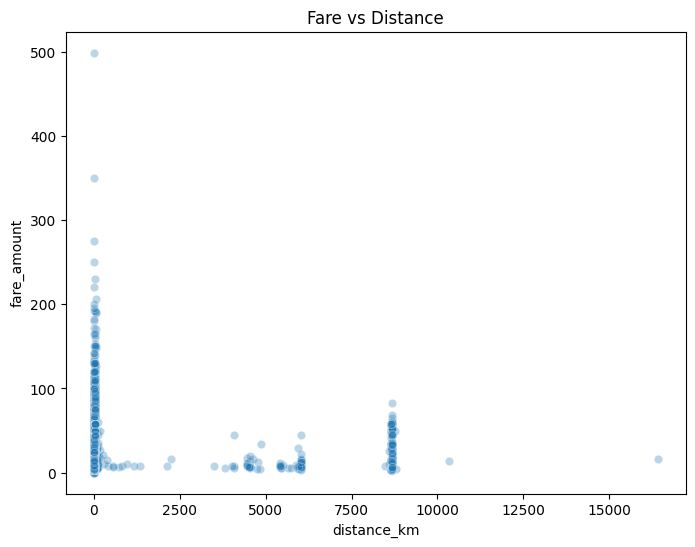

In [19]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='distance_km', y='fare_amount', data=df, alpha=0.3)
plt.title("Fare vs Distance")
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Latitude and Longitude Values** : \
latitude: -90° to +90° \
longitude: -180° to +180

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Pickup

In [20]:
invalid_coordinates = df[df['pickup_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
42931506,4.9,2012-04-28 00:58:00 UTC,-748.016667,40.739957,-74.003570,40.734192,1,3828.760217
1055960,33.7,2011-11-05 23:26:00 UTC,-735.200000,40.770092,-73.980187,40.765530,1,4852.352520
33249845,15.7,2011-11-05 00:22:00 UTC,-1340.648410,1644.421482,-3356.666300,872.697628,1,16409.239135
16826862,12.9,2011-10-14 19:04:00 UTC,-736.216667,40.767035,-73.982377,40.725562,1,4773.694612
9421322,7.3,2009-08-26 11:55:00 UTC,-768.550000,40.757812,-73.997040,40.740007,1,2136.043688
25264921,4.1,2010-05-12 12:19:00 UTC,-735.433332,40.740605,-74.006373,40.739607,1,4838.094257
44787414,4.1,2012-07-21 16:19:00 UTC,-736.400000,40.774307,-73.982215,40.769672,5,4757.216153


We consider that all above observations minus the third are decimal point error. So we will correct all and eliminate '33249845'. 

In [21]:
df.drop([33249845], axis=0, inplace=True)

In [22]:
df.loc[df['pickup_longitude'] < -180, 'pickup_longitude'] *= 0.1

In [23]:
df.loc[42931506]

fare_amount                              4.9
pickup_datetime      2012-04-28 00:58:00 UTC
pickup_longitude                  -74.801667
pickup_latitude                    40.739957
dropoff_longitude                  -74.00357
dropoff_latitude                   40.734192
passenger_count                            1
distance_km                      3828.760217
Name: 42931506, dtype: object

In [24]:
invalid_coordinates = df[df['pickup_longitude']> 180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


All checked.

In [25]:
invalid_coordinates = df[df['pickup_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [26]:
invalid_coordinates = df[df['pickup_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
14257861,8.1,2012-03-11 07:24:00 UTC,-73.960828,404.433332,-73.988357,40.769037,1,407.457236
2849369,8.5,2012-06-13 05:45:00 UTC,-73.951385,401.066667,-73.982110,40.754117,1,34.849750
23566642,16.1,2011-05-18 13:24:00 UTC,57.418457,1292.016128,1153.572603,-881.985513,1,2246.893301


In [27]:
df.drop([23566642], axis=0, inplace=True)

In [28]:
df.loc[df['pickup_latitude']> 90, 'pickup_latitude'] *= 0.1

In [29]:
df.loc[14257861]

fare_amount                              8.1
pickup_datetime      2012-03-11 07:24:00 UTC
pickup_longitude                  -73.960828
pickup_latitude                    40.443333
dropoff_longitude                 -73.988357
dropoff_latitude                   40.769037
passenger_count                            1
distance_km                       407.457236
Name: 14257861, dtype: object

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Dropoff

In [30]:
invalid_coordinates = df[df['dropoff_longitude']< -180]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
5634081,15.7,2012-06-16 10:04:00 UTC,-74.016055,40.715155,-737.916665,40.697862,2,4644.267681


In [31]:
df.loc[df['dropoff_longitude']< -180, 'dropoff_longitude'] *= 0.1

In [32]:
invalid_coordinates = df[df['dropoff_longitude']> 180]
invalid_coordinates 

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [33]:
invalid_coordinates = df[df['dropoff_latitude']< -90]
invalid_coordinates	

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


In [34]:
invalid_coordinates = df[df['dropoff_latitude']> 90]
invalid_coordinates

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
39981694,13.7,2012-01-20 11:50:00 UTC,-74.011042,40.70978,-73.983163,493.533332,4,10321.507661


In [35]:
df.loc[df['dropoff_latitude']> 90, 'dropoff_latitude'] *= 0.1

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Time** - pickup_datetime

pickup_datetime ver se ha negativos

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
    
**Nº passagers** - passenger_count

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Negative Count

In [36]:
negative_count = ['passenger_count']
df[((df[negative_count]) < 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">Not Integers

In [37]:
not_int = ['passenger_count']
df[((df[not_int]) %1 != 0).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
Max 7 Passengers

In [38]:
max_count = ['passenger_count']
df[((df[max_count]) > 7).any(axis=1)]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
35893772,11.7,2010-12-28 08:20:00 UTC,-73.937795,40.758498,-73.937835,40.758415,208,0.009825


Passenger_count all good.

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
2.2.2. Handling Inconsistent Records <b>- Second Rule: 

<div style="background-color:#0047AB; padding:20px; border-radius:10px; border-left:8px">

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. How to Handle Missing Values 

In [39]:
df.info() #this gives us a summary of the dataset, that includes the datatypes of the columns, which is useful for later analysis

<class 'pandas.core.frame.DataFrame'>
Index: 199979 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199979 non-null  float64
 1   pickup_datetime    199979 non-null  object 
 2   pickup_longitude   199979 non-null  float64
 3   pickup_latitude    199979 non-null  float64
 4   dropoff_longitude  199978 non-null  float64
 5   dropoff_latitude   199978 non-null  float64
 6   passenger_count    199979 non-null  int64  
 7   distance_km        199978 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 17.8+ MB


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
Firstly, we need to understand how many missing values are in our dataset. With this function, we are able to see how many are in each column.

In [40]:
df.isna().sum()

fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
distance_km          1
dtype: int64

In [41]:
df[df['dropoff_longitude'].isna()]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km
32736015,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0,NaN


The two missing values in the dataset are in the row with index 32736015, that are the coordinates of dropoff, so we will remove this row.

In [42]:
df = df.drop(32736015)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
<b>2.2.5. Outliers - How should we treat them?

Before doing any steps regarding the outliers, we need to understand the data and its purpose. There are a lot of things that we are able to do: 
- We can fix outliers values when values are clearly unrealistic by replacing their values with the median.
- We can also just remove them if they are few, clearly erros or just not important fot the analysis.
- However, we can winsorize extreme values instead of removing them. This keeps data however reduces distortion.
- We can use transformation , by applying the log(x) or the sqrt(x) functions.

Note: It is important to understand the context of outliers before doing any changes or steps regarding them.

Basic statistics of numerical columns (all columns):

In [43]:
print("Basic Statistics")
print(df.describe())

Basic Statistics
         fare_amount  pickup_longitude  pickup_latitude  dropoff_longitude  \
count  199978.000000     199978.000000    199978.000000      199978.000000   
mean       11.362500        -72.502101        39.918098         -72.512651   
std         9.897148         10.448932         6.129897          10.408635   
min         0.000000        -93.824668       -74.015515         -75.458979   
25%         6.000000        -73.992065        40.734792         -73.991407   
50%         8.500000        -73.981822        40.752591         -73.980092   
75%        12.500000        -73.967152        40.767157         -73.963658   
max       499.000000         40.808425        48.018760          40.831932   

       dropoff_latitude  passenger_count    distance_km  
count     199978.000000    199978.000000  199978.000000  
mean          39.922648         1.684490      20.677378  
std            6.115886         1.385969     380.213013  
min          -74.015750         0.000000       0

In [44]:
df_melted = df_scaled.melt(var_name='Variable', value_name='Value')

plt.figure(figsize=(14,6))
sns.boxplot(x='Variable', y='Value', data=df_melted)

plt.xticks(rotation=45)
plt.title("Standardized Boxplots of All Variables")
plt.show()

NameError: name 'df_scaled' is not defined

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Datetime 

In [ ]:
# Parse datetime
# Extract the pickup_datetime column (it's currently the second column)
# The first column is an index, so pickup_datetime is at position 1
datetime_col = df.columns[1]  # This should be 'pickup_datetime'

# Convert to datetime, handling the UTC string format
df['pickup_datetime'] = pd.to_datetime(df[datetime_col], utc=True)

# Extract datetime components
df['pickup_date'] = df['pickup_datetime'].dt.date
df['pickup_hour'] = df['pickup_datetime'].dt.hour
df['pickup_day'] = df['pickup_datetime'].dt.day
df['pickup_month'] = df['pickup_datetime'].dt.month
df['pickup_year'] = df['pickup_datetime'].dt.year
df['pickup_dayofweek'] = df['pickup_datetime'].dt.dayofweek  # Monday=0, Sunday=6
df['pickup_quarter'] = df['pickup_datetime'].dt.quarter

# Create day/night indicator (6 AM - 6 PM = day)
df['is_day'] = ((df['pickup_hour'] >= 6) & (df['pickup_hour'] < 18)).astype(int)

# Create weekend indicator
df['is_weekend'] = (df['pickup_dayofweek'] >= 5).astype(int)

print("Datetime features created:")
print(f"- pickup_hour: {df['pickup_hour'].nunique()} unique hours")
print(f"- pickup_dayofweek: {df['pickup_dayofweek'].nunique()} unique days")
print(f"- pickup_month: {df['pickup_month'].nunique()} unique months")
print(f"- pickup_year: {sorted(df['pickup_year'].unique())}")
print(f"- is_day: {df['is_day'].sum()} day trips, {len(df)-df['is_day'].sum()} night trips")
print(f"- is_weekend: {df['is_weekend'].sum()} weekend trips")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Feature Engineering

In [ ]:
# Create additional features

# Time-based features
df['hour_category'] = pd.cut(df['pickup_hour'], 
                                     bins=[0, 6, 12, 18, 24], 
                                     labels=['Late Night', 'Morning', 'Afternoon', 'Evening'],
                                     right=False)

df['day_name'] = df['pickup_dayofweek'].map({
    0: 'Monday', 1: 'Tuesday', 2: 'Wednesday', 3: 'Thursday',
    4: 'Friday', 5: 'Saturday', 6: 'Sunday'
})

df['month_name'] = df['pickup_month'].map({
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
})

# Season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['pickup_month'].apply(get_season)

# Rush hour indicator (7-9 AM and 4-7 PM on weekdays)
df['is_rush_hour'] = ((~df['is_weekend'].astype(bool)) & 
                              (((df['pickup_hour'] >= 7) & (df['pickup_hour'] <= 9)) |
                               ((df['pickup_hour'] >= 16) & (df['pickup_hour'] <= 19)))).astype(int)

print("New categorical features created:")
print(f"- hour_category: {df['hour_category'].unique()}")
print(f"- day_name: {df['day_name'].unique()}")
print(f"- month_name: {df['month_name'].unique()}")
print(f"- season: {df['season'].unique()}")
print(f"- is_rush_hour: {df['is_rush_hour'].sum()} rush hour trips")

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.3. Exploratory Data Analysis

In [ ]:
# Create figure and axes
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Common style
blue_main = '#1f77b4'
blue_light = '#6baed6'

# --- Fare distribution ---
ax = axes[0, 0]
ax.hist(df['fare_amount'], bins=50, edgecolor='black', alpha=0.8, color=blue_main)
ax.set_title('Fare Amount Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Fare ($)')
ax.set_ylabel('Frequency')

# --- Passenger count ---
ax = axes[0, 1]
passenger_counts = df['passenger_count'].value_counts().sort_index()
ax.bar(passenger_counts.index, passenger_counts.values,
       edgecolor='black', alpha=0.8, color=blue_main)
ax.set_title('Passenger Count Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Passengers')
ax.set_ylabel('Number of Trips')

# --- Hourly trips ---
ax = axes[0, 2]
hourly_trips = df['pickup_hour'].value_counts().sort_index()
ax.plot(hourly_trips.index, hourly_trips.values,
        marker='o', linewidth=2, markersize=6, color=blue_main)
ax.set_title('Trips by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour')
ax.set_ylabel('Number of Trips')
ax.grid(True, alpha=0.3)

# --- Day of week ---
ax = axes[1, 0]
dow_trips = df['day_name'].value_counts()
ax.bar(dow_trips.index, dow_trips.values,
       edgecolor='black', alpha=0.8, color=blue_main)
ax.set_title('Trips by Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day')
ax.set_ylabel('Number of Trips')
ax.tick_params(axis='x', rotation=45)

# --- Month ---
ax = axes[1, 1]
month_trips = df['month_name'].value_counts()
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
month_trips = month_trips.reindex(month_order)

ax.bar(month_trips.index, month_trips.values,
       edgecolor='black', alpha=0.8, color=blue_light)
ax.set_title('Trips by Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Trips')
ax.tick_params(axis='x', rotation=45)

# --- Year ---
ax = axes[1, 2]
year_trips = df['pickup_year'].value_counts().sort_index()
ax.bar(year_trips.index.astype(str), year_trips.values,
       edgecolor='black', alpha=0.8, color=blue_light)
ax.set_title('Trips by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Trips')

# Layout
plt.tight_layout()
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">
    
# Exploratory Data Analysis – Trip Distributions

## 1. Fare Amount Distribution
The fare distribution is **heavily right-skewed**, with the majority of trips concentrated at lower fare values.  

- Most fares fall within a relatively small range near the lower end  
- There are **extreme outliers** (very high fares), which may represent:
  - Long-distance trips  
  - Data entry anomalies  

**Insight:**  
The skewness suggests that the **median fare** is a more reliable measure than the mean.

---

## 2. Passenger Count Distribution
The passenger count shows a strong imbalance toward single passengers:

- Most trips involve **1 passenger**  
- Counts decrease significantly for 2–4 passengers  
- Very high passenger counts are rare and likely **outliers or errors**  

**Insight:**  
Taxi usage is predominantly **individual-based travel**.

---

## 3. Trips by Hour of Day
Trip activity varies clearly throughout the day:

- **Early morning (3–5 AM):** Lowest activity  
- **Morning (7–10 AM):** Rapid increase (commute hours)  
- **Evening (5–9 PM):** Peak demand  

**Insight:**  
There is a clear **commuting pattern**, with evening demand slightly higher—likely due to both work and leisure trips.

---

## 4. Trips by Day of Week
Trip counts are relatively balanced but show slight variation:

- **Friday and Saturday:** Highest activity  
- **Monday:** Lowest activity  

**Insight:**  
Demand increases toward the **end of the week**, likely due to social and weekend activities.

---

## 5. Trips by Month
Monthly patterns indicate mild seasonality:

- **Spring (Mar–May):** Higher activity  
- **Late summer (Jul–Aug):** Noticeable dip  
- Other months remain fairly stable  

**Insight:**  
Seasonal behavior (weather, holidays, travel) influences trip frequency.

---

## 6. Trips by Year
Yearly distribution shows:

- Slight growth up to around **2012**  
- Mild decline afterward  
- A sharp drop in **2015**  

**Important:**  
The drop in 2015 is likely due to **incomplete data**, not an actual decline.

---

# Key Takeaways

- Trips are mostly **low-cost, short-distance, single-passenger**  
- Strong **time-based patterns**:
  - Peak hours: commuting times  
  - Peak days: end of week  
- Presence of **outliers and possible data quality issues**  
- Mild **seasonality and yearly variation**

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.4. Correlation Analysis

In [ ]:
# Select numerical columns
numerical_cols = ['fare_amount', 'passenger_count', 'pickup_hour', 'pickup_day', 
                  'pickup_month', 'pickup_dayofweek', 'is_day', 'is_weekend', 'is_rush_hour']

available_numerical_cols = [col for col in numerical_cols if col in df.columns]
print(f"Using columns: {available_numerical_cols}")

correlation_matrix = df[available_numerical_cols].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

# Custom blue-only colormap
blue_diverging = LinearSegmentedColormap.from_list(
    "blue_diverging",
    ["#e3f2fd", "#90caf9", "#0d47a1"]  # light → medium → dark blue
)

sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            cmap=blue_diverging,
            center=0,
            square=True, 
            linewidths=1, 
            cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1,
            annot_kws={"size": 10})

plt.title('Feature Correlation Matrix (Lower Triangle)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nTop correlations with fare_amount:")
if 'fare_amount' in correlation_matrix.columns:
    fare_corr = correlation_matrix['fare_amount'].sort_values(ascending=False)
    print(fare_corr)

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.2.5. Average Fare Analysis

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Blue palette
blue_main = '#1f77b4'
blue_light = '#6baed6'
blue_dark = '#0d47a1'

# --- By hour ---
hourly_avg_fare = df.groupby('pickup_hour')['fare_amount'].mean()
axes[0, 0].plot(hourly_avg_fare.index, hourly_avg_fare.values,
                marker='o', linewidth=2, markersize=6, color=blue_main)
axes[0, 0].set_title('Average Fare by Hour', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('Average Fare ($)')
axes[0, 0].grid(True, alpha=0.3)

# --- By day of week ---
if 'day_name' in df.columns:
    dow_avg_fare = df.groupby('day_name')['fare_amount'].mean()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_avg_fare = dow_avg_fare.reindex(day_order)
    
    axes[0, 1].bar(dow_avg_fare.index, dow_avg_fare.values,
                   edgecolor='black', alpha=0.8, color=blue_main)
    axes[0, 1].set_title('Average Fare by Day', fontsize=14, fontweight='bold')
    axes[0, 1].set_xlabel('Day')
    axes[0, 1].set_ylabel('Average Fare ($)')
    axes[0, 1].tick_params(axis='x', rotation=45)

# --- By month ---
if 'month_name' in df.columns:
    month_avg_fare = df.groupby('month_name')['fare_amount'].mean()
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    month_avg_fare = month_avg_fare.reindex(month_order)
    
    axes[0, 2].bar(month_avg_fare.index, month_avg_fare.values,
                   edgecolor='black', alpha=0.8, color=blue_light)
    axes[0, 2].set_title('Average Fare by Month', fontsize=14, fontweight='bold')
    axes[0, 2].set_xlabel('Month')
    axes[0, 2].set_ylabel('Average Fare ($)')
    axes[0, 2].tick_params(axis='x', rotation=45)

# --- By season ---
if 'season' in df.columns:
    season_avg_fare = df.groupby('season')['fare_amount'].mean()
    season_order = ['Winter', 'Spring', 'Summer', 'Fall']
    season_avg_fare = season_avg_fare.reindex(season_order)
    
    axes[1, 0].bar(season_avg_fare.index, season_avg_fare.values,
                   edgecolor='black', alpha=0.8, color=blue_dark)
    axes[1, 0].set_title('Average Fare by Season', fontsize=14, fontweight='bold')
    axes[1, 0].set_xlabel('Season')
    axes[1, 0].set_ylabel('Average Fare ($)')

# --- By hour category ---
if 'hour_category' in df.columns:
    hour_cat_avg_fare = df.groupby('hour_category')['fare_amount'].mean()
    cat_order = ['Late Night', 'Morning', 'Afternoon', 'Evening']
    hour_cat_avg_fare = hour_cat_avg_fare.reindex(cat_order)
    
    axes[1, 1].bar(hour_cat_avg_fare.index, hour_cat_avg_fare.values,
                   edgecolor='black', alpha=0.8, color=blue_main)
    axes[1, 1].set_title('Average Fare by Time of Day', fontsize=14, fontweight='bold')
    axes[1, 1].set_xlabel('Time Category')
    axes[1, 1].set_ylabel('Average Fare ($)')
    axes[1, 1].tick_params(axis='x', rotation=45)

# --- By passenger count ---
pass_avg_fare = df.groupby('passenger_count')['fare_amount'].mean()
axes[1, 2].bar(pass_avg_fare.index, pass_avg_fare.values,
               edgecolor='black', alpha=0.8, color=blue_light)
axes[1, 2].set_title('Average Fare by Passenger Count', fontsize=14, fontweight='bold')
axes[1, 2].set_xlabel('Passengers')
axes[1, 2].set_ylabel('Average Fare ($)')

plt.tight_layout()
plt.show()

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px solid #0047AB;">
<h3><b>Part B – Clustering </b></h3>

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 1.Select features for clustering

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for professional plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Check what columns we have
print("\nExisting columns in dataset:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")


Existing columns in dataset:
['fare_amount', 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude', 'passenger_count', 'distance_km']

Dataset shape: (199978, 8)


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 199978 entries, 24238194 to 11951496
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        199978 non-null  float64
 1   pickup_datetime    199978 non-null  object 
 2   pickup_longitude   199978 non-null  float64
 3   pickup_latitude    199978 non-null  float64
 4   dropoff_longitude  199978 non-null  float64
 5   dropoff_latitude   199978 non-null  float64
 6   passenger_count    199978 non-null  int64  
 7   distance_km        199978 non-null  float64
dtypes: float64(6), int64(1), object(1)
memory usage: 13.7+ MB


<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 2.Scale data

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

<div style="background-color:#EFF5FF; padding:20px; border-radius:10px; border-left:8px">   
<b> 3.Find optimal number of clusters